In [1]:
import json
import random
import copy
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    precision_score, recall_score, f1_score, roc_curve, auc
)

# Grafiklerin şık görünmesi için ayarlar
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
random.seed(42)

print("✅ Blok 1: Tüm kütüphaneler başarıyla hafızaya yüklendi!")

✅ Blok 1: Tüm kütüphaneler başarıyla hafızaya yüklendi!


In [2]:
# --- 1. VERİ OKUMA VE MUTATION (VERİ ÜRETİMİ) ---
print("⏳ 1. ADIM: Ham veriler okunuyor...")
ast_verileri = []
with open("archive/py150/python100k_train.json", "r") as f:
    for i, satir in enumerate(f):
        if i >= 20000: # Bilgisayarın kilitlenmemesi için güvenli veri sınırımız
            break
        ast_verileri.append(json.loads(satir))

df = pd.DataFrame({"ast_nodes": ast_verileri})
df["label"] = 0 

def ast_boz(ast_liste):
    bozuk_ast = json.loads(json.dumps(ast_liste))
    if len(bozuk_ast) > 2:
        secilen_index = random.randint(1, len(bozuk_ast) - 1)
        hata_turu = random.choice(["tip_degistir", "cocuk_sil", "deger_sil"])
        if hata_turu == "tip_degistir": bozuk_ast[secilen_index]["type"] = "HataliDugum"
        elif hata_turu == "cocuk_sil":
            if "children" in bozuk_ast[secilen_index]: del bozuk_ast[secilen_index]["children"]
            else: bozuk_ast[secilen_index]["type"] = "HataliDugum" 
        elif hata_turu == "deger_sil":
            if "value" in bozuk_ast[secilen_index]: del bozuk_ast[secilen_index]["value"]
            else: bozuk_ast[secilen_index]["type"] = "HataliDugum"
    return bozuk_ast

print("✨ Sentetik hatalar oluşturuluyor...")
df_bozulacaklar = df.sample(frac=0.5, random_state=42).copy()
df_bozulacaklar["ast_nodes"] = df_bozulacaklar["ast_nodes"].apply(ast_boz)
df_bozulacaklar["label"] = 1  

final_df = pd.concat([df, df_bozulacaklar], ignore_index=True)
df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# --- 2. VERI SIZINTISINI ÖNLEYEN PREPROCESSING ---
print("⚙️ 2. ADIM: Güvenli Preprocessing ve Train-Test Ayrımı...")
def ast_tiplerini_cikar(ast_liste):
    return " ".join([dugum.get("type", "") for dugum in ast_liste])

df['ast_text'] = df['ast_nodes'].apply(ast_tiplerini_cikar)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['ast_text'], df['label'], test_size=0.20, random_state=42, stratify=df['label']
)

# TF-IDF Normalizasyonu (Gürültüyü azaltmak için min_df=2 ekledik)
vectorizer = TfidfVectorizer(max_features=1000, min_df=2)
X_train_vektor = vectorizer.fit_transform(X_train_raw)
X_test_vektor = vectorizer.transform(X_test_raw)

print("🚀 Blok 2: Veriler başarıyla hazırlandı ve vektörleştirildi!")

⏳ 1. ADIM: Ham veriler okunuyor...
✨ Sentetik hatalar oluşturuluyor...
⚙️ 2. ADIM: Güvenli Preprocessing ve Train-Test Ayrımı...
🚀 Blok 2: Veriler başarıyla hazırlandı ve vektörleştirildi!


In [3]:
print("--- 3. ADIM: YAPAY ZEKA MODELLERİ OPTİMİZE EDİLİYOR ---")

# A. Logistic Regression İnce Ayar
print("1. Logistic Regression için en iyi parametreler aranıyor (GridSearch)...")
log_param_grid = {'C': [0.1, 1.0, 10.0]}
log_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), log_param_grid, cv=3, scoring='f1', n_jobs=-1)
log_grid.fit(X_train_vektor, y_train)
best_log_model = log_grid.best_estimator_

# B. Random Forest İnce Ayar
print("2. Random Forest için en iyi parametreler aranıyor (GridSearch)...")
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 15]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_vektor, y_train)
best_rf_model = rf_grid.best_estimator_

print("🏆 Blok 3: En iyi yapay zeka modelleri başarıyla keşfedildi!")

--- 3. ADIM: YAPAY ZEKA MODELLERİ OPTİMİZE EDİLİYOR ---
1. Logistic Regression için en iyi parametreler aranıyor (GridSearch)...
2. Random Forest için en iyi parametreler aranıyor (GridSearch)...
🏆 Blok 3: En iyi yapay zeka modelleri başarıyla keşfedildi!


--- 4. ADIM: DETAYLI PERFORMANS RAPORLAMASI ---

🏆 [LOJİSTİK REGRESYON (OPTIMIZED)] DETAYLI PERFORMANS RAPORU
              precision    recall  f1-score   support

 Hatasız (0)       0.80      1.00      0.89      4000
  Hatalı (1)       1.00      0.50      0.67      2000

    accuracy                           0.83      6000
   macro avg       0.90      0.75      0.78      6000
weighted avg       0.87      0.83      0.82      6000



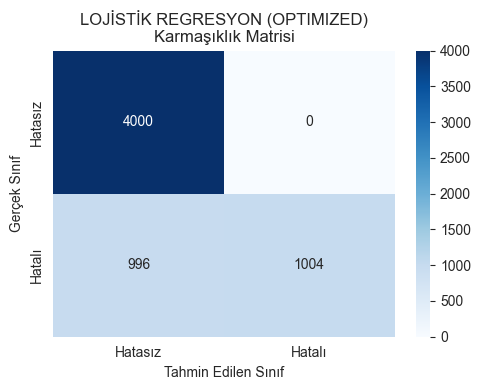

📊 3-Fold Çapraz Doğrulama Skorları: [0.8332 0.8354 0.8229]
📌 Ortalama Güvenilirlik Doğruluğu: % 83.05

🏆 [RASTGELE ORMAN (OPTIMIZED)] DETAYLI PERFORMANS RAPORU
              precision    recall  f1-score   support

 Hatasız (0)       0.85      1.00      0.92      4000
  Hatalı (1)       1.00      0.65      0.79      2000

    accuracy                           0.88      6000
   macro avg       0.92      0.82      0.85      6000
weighted avg       0.90      0.88      0.87      6000



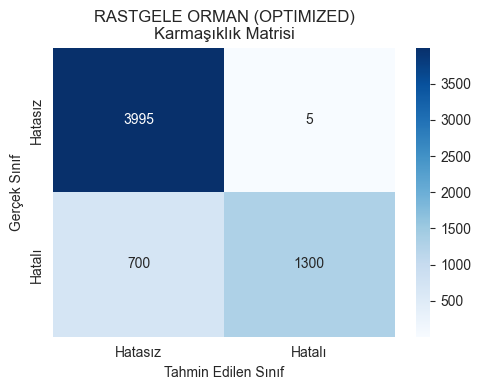

📊 3-Fold Çapraz Doğrulama Skorları: [0.8872 0.8825 0.8815]
📌 Ortalama Güvenilirlik Doğruluğu: % 88.38

--- 5. ADIM: EN BAŞARILI MODEL PAKETLENİYOR ---
🏆 Test setindeki F1-Skoruna göre seçilen en başarılı model: Random Forest

💾 Blok 4 BAŞARIYLA BİTTİ! 'Random Forest' modeli ve TF-IDF sözlüğü klasöre paketlendi!


In [4]:
print("--- 4. ADIM: DETAYLI PERFORMANS RAPORLAMASI ---")

modeller = {
    "LOJİSTİK REGRESYON (OPTIMIZED)": best_log_model,
    "RASTGELE ORMAN (OPTIMIZED)": best_rf_model
}

for model_adi, model in modeller.items():
    tahminler = model.predict(X_test_vektor)
    
    print("\n" + "="*60)
    print(f"🏆 [{model_adi}] DETAYLI PERFORMANS RAPORU")
    print("="*60)
    print(classification_report(y_test, tahminler, target_names=["Hatasız (0)", "Hatalı (1)"]))
    
    # Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, tahminler)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Hatasız", "Hatalı"], yticklabels=["Hatasız", "Hatalı"])
    plt.title(f"{model_adi}\nKarmaşıklık Matrisi")
    plt.xlabel("Tahmin Edilen Sınıf")
    plt.ylabel("Gerçek Sınıf")
    plt.tight_layout()
    plt.show()
    
    # Kross-Validasyon (Güvenilirlik Testi)
    cv_skorlar = cross_val_score(model, X_train_vektor, y_train, cv=3, scoring='accuracy')
    print(f"📊 3-Fold Çapraz Doğrulama Skorları: {cv_skorlar.round(4)}")
    print(f"📌 Ortalama Güvenilirlik Doğruluğu: % {cv_skorlar.mean()*100:.2f}")

# --- 5. EN İYİ MODELİ SEÇME VE MODEL KAYDETME ---
print("\n--- 5. ADIM: EN BAŞARILI MODEL PAKETLENİYOR ---")

log_f1 = f1_score(y_test, best_log_model.predict(X_test_vektor))
rf_f1 = f1_score(y_test, best_rf_model.predict(X_test_vektor))

if rf_f1 > log_f1:
    nihai_model = best_rf_model
    secilen_isim = "Random Forest"
else:
    nihai_model = best_log_model
    secilen_isim = "Logistic Regression"

print(f"🏆 Test setindeki F1-Skoruna göre seçilen en başarılı model: {secilen_isim}")

os.makedirs("processed_data", exist_ok=True)

# Modellere zarar gelmemesi için güvenli joblib kütüphanesiyle kaydediyoruz
joblib.dump(nihai_model, 'yapay_zeka_modeli.pkl')
joblib.dump(vectorizer, 'processed_data/fitted_vectorizer.pkl')

print(f"\n💾 Blok 4 BAŞARIYLA BİTTİ! '{secilen_isim}' modeli ve TF-IDF sözlüğü klasöre paketlendi!")